# Trying to build Micrograd from scratch

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [65]:
class Value():
    def __init__(self, data, label='', _op='', _children={}):
        self.data = data
        self._backward = lambda: None
        self.grad = 0.0
        self.label = label
        self._op = _op
        self._prev = _children

    def __repr__(self):
        return f"{self.label}'s value is: {self.data}" 
    
    def __add__(self, other):
        sum = self.data + other.data
        out = Value(sum, '', '+', {self, other})

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        prod = self.data * other.data
        out = Value(prod, '', '*', {self, other})

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other):
        return self * other

    def __div__(self, other):
        val = self.data / other.data
        out = Value(val, '', '/', {self, other})
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, '', 'tanh', {self})

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out

    def backward(self):
        # should take current gradient, set it to 1. Becuase dL/dL = 1.
        # then, get the reversed topological sort of all of current node's predecessors
        # and, keep applying _backward() to them, one by one.

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

In [66]:
a = Value(2, 'a')
b = Value(-4, 'b')
c = a + b; c.label = 'c'
f = Value(-1, 'f')
o = c * f; o.label = 'o'

L = o.tanh()
L.label = 'L'

In [67]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

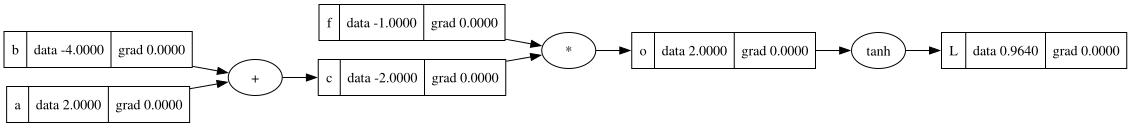

In [68]:
draw_dot(L)

In [69]:
L.backward()

In [74]:
from numpy import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

class MLP:
    def __init__(self, nin, nout):
        out = [nin] + nout
        self.layers = [Layer(out[i], out[i+1]) for i in range(len(nout))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

### So, what happens when we run 'n = MLP(3, [4, 4, 1])', and then run 'n(x)', where x = [2.0, 3.0, -1.0]

- So, first of all, when we run 'n = MLP(3, [4, 4, 1])', a list is created: [3, 4, 4, 1]. These represent the number of neurons in each layer.
- So, step 1 is to define layers with these dimensions. But, layers need input and output diemensions, so, InputLayer: 3->4, HiddenLayer1: 4->4, HiddenLayer2: 4->1.
- And then, when we call n(x), we take the input vector: [2.0, 3.0, -1.0], and first apply it to the input layer, and get back x = [z1, z2, z3]. And, then, this updated x goes through the HiddenLayer1, and gives us x = [z1, z2, z3, z4]. Now, this updated x is fed to HiddenLayer2, which will give us x = [z], a single value, according to it's nout.
- And, this is the final value of the network.

In [76]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

's value is: 0.5439425432766668